In [1]:
import json
import pandas as pd
from tqdm import tqdm
import re
import numpy as np
import matplotlib.pyplot as plt


# FDA Data Stats

In [19]:
df_orig = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_drugs_labels_full.csv")
df_orig.shape

(26306, 22)

In [20]:
df_orig.columns

Index(['application_number', 'sponsor_name', 'submission_type',
       'submission_status_date', 'submission_class_code_description', 'year',
       'brand_name', 'dosage_form', 'route', 'marketing_status',
       'active_ingredients', 'openfda_brand_name', 'openfda_generic_name',
       'openfda_route', 'openfda_substance_name', 'label_brand_name',
       'label_generic_name', 'label_manufacturer_name', 'label_substance_name',
       'indications_first_sent', 'indications_and_usage', 'clinical_studies'],
      dtype='object')

In [21]:
df_orig.head()

,application_number,sponsor_name,submission_type,submission_status_date,submission_class_code_description,year,brand_name,dosage_form,route,marketing_status,...,openfda_generic_name,openfda_route,openfda_substance_name,label_brand_name,label_generic_name,label_manufacturer_name,label_substance_name,indications_first_sent,indications_and_usage,clinical_studies
0,ANDA076194,WATSON LABS,ORIG,20020701,NaN,2002,LISINOPRIL AND HYDROCHLOROTHIAZIDE,TABLET,ORAL,Prescription,...,LISINOPRIL AND HYDROCHLOROTHIAZIDE,ORAL,"HYDROCHLOROTHIAZIDE, LISINOPRIL",Lisinopril and Hydrochlorothiazide,LISINOPRIL AND HYDROCHLOROTHIAZIDE,"Actavis Pharma, Inc.","HYDROCHLOROTHIAZIDE, LISINOPRIL",INDICATIONS AND USAGE Lisinopril and Hydrochlo...,INDICATIONS AND USAGE Lisinopril and Hydrochlo...,[]
1,ANDA076206,ROCKWELL MEDCL,ORIG,20030917,NaN,2003,CALCITRIOL,INJECTABLE,INJECTION,Discontinued,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ANDA076212,APOTEX,ORIG,20040616,NaN,2004,CARBIDOPA AND LEVODOPA,"TABLET, EXTENDED RELEASE",ORAL,Discontinued,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ANDA076215,FOUGERA PHARMS,ORIG,20031209,NaN,2003,BETAMETHASONE DIPROPIONATE,"CREAM, AUGMENTED",TOPICAL,Prescription,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ANDA076224,PHARMOBEDIENT,ORIG,20030509,NaN,2003,FLUTAMIDE,CAPSULE,ORAL,Discontinued,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df_orig[df_orig['submission_class_code_description'].str.contains("Type 3", na=False)][['application_number','submission_class_code_description','indications_first_sent']]


,application_number,submission_class_code_description,indications_first_sent
63,NDA017453,Type 3 - New Dosage Form,INDICATIONS AND USAGE PROGLYCEM is indicated f...
95,NDA017516,Type 3 - New Dosage Form,NaN
145,NDA017603,Type 3 - New Dosage Form,NaN
225,NDA017703,Type 3 - New Dosage Form,NaN
268,NDA017814,Type 3 - New Dosage Form,NaN
...,...,...,...
26192,NDA016936,Type 3 - New Dosage Form,NaN
26198,NDA016954,Type 3 - New Dosage Form,NaN
26291,NDA017352,Type 3 - New Dosage Form,NaN
26292,NDA017354,Type 3 - New Dosage Form,NaN


In [23]:
df_orig[df_orig['active_ingredients'].str.contains("MODAFINIL", na=False)][['active_ingredients', 'year','application_number','submission_class_code_description','indications_first_sent']]


,active_ingredients,year,application_number,submission_class_code_description,indications_first_sent
54,MODAFINIL,2012,ANDA076594,NaN,NaN
167,MODAFINIL,2007,ANDA077892,NaN,NaN
717,ARMODAFINIL,2012,ANDA200156,Not Applicable,NaN
2731,MODAFINIL,2005,ANDA076596,NaN,NaN
5323,MODAFINIL,2004,ANDA076597,NaN,NaN
6363,ARMODAFINIL,2018,ANDA206069,NaN,1 INDICATIONS AND USAGE Armodafinil tablets ar...
7209,MODAFINIL,1998,NDA020717,Type 1 - New Molecular Entity,1 INDICATIONS AND USAGE PROVIGIL is indicated ...
9135,MODAFINIL,2017,ANDA207196,NaN,1 INDICATIONS AND USAGE Modafinil tablets are ...
12571,ARMODAFINIL,2007,NDA021875,Type 5 - New Formulation or New Manufacturer,1 INDICATIONS AND USAGE Armodafinil tablets ar...
13300,MODAFINIL,2014,ANDA077667,NaN,1 INDICATIONS AND USAGE Modafinil tablets are ...


In [24]:
df_orig[df_orig['active_ingredients'].str.contains("MODAFINIL", na=False)][['active_ingredients','year','application_number','submission_class_code_description','indications_first_sent']].to_csv("out/MODAFINIL_example_fda_labels.csv", index=False)

In [25]:
df_all = df_orig.copy()[['application_number', 'submission_class_code_description', 'sponsor_name', 'indications_and_usage', 'year']]

sdesc = df_all["submission_class_code_description"].fillna("")
keep_mask = sdesc.str.match(r"(?i)^\s*type\s*(1)\b")
df_novel = df_all[keep_mask].copy()
df_all['is_novel_drug_therapy'] = keep_mask

repurposed_mask = sdesc.str.match(r"(?i)^\s*type\s*3\b")
df_all['is_repurposed_therapy'] = repurposed_mask

df_all.head()

,application_number,submission_class_code_description,sponsor_name,indications_and_usage,year,is_novel_drug_therapy,is_repurposed_therapy
0,ANDA076194,NaN,WATSON LABS,INDICATIONS AND USAGE Lisinopril and Hydrochlo...,2002,False,False
1,ANDA076206,NaN,ROCKWELL MEDCL,NaN,2003,False,False
2,ANDA076212,NaN,APOTEX,NaN,2004,False,False
3,ANDA076215,NaN,FOUGERA PHARMS,NaN,2003,False,False
4,ANDA076224,NaN,PHARMOBEDIENT,NaN,2003,False,False


In [26]:
df_all.shape

(26306, 7)

In [27]:
df_all.is_novel_drug_therapy.sum(), df_all.is_repurposed_therapy.sum()

(1794, 1680)

In [28]:
df_all[df_all.is_repurposed_therapy]

,application_number,submission_class_code_description,sponsor_name,indications_and_usage,year,is_novel_drug_therapy,is_repurposed_therapy
63,NDA017453,Type 3 - New Dosage Form,TEVA BRANDED PHARM,INDICATIONS AND USAGE PROGLYCEM is indicated f...,1976,False,True
95,NDA017516,Type 3 - New Dosage Form,PFIZER,NaN,1974,False,True
145,NDA017603,Type 3 - New Dosage Form,SANOFI AVENTIS US,NaN,1975,False,True
225,NDA017703,Type 3 - New Dosage Form,ABBOTT,NaN,1976,False,True
268,NDA017814,Type 3 - New Dosage Form,ZYLA LIFE SCIENCES,NaN,1984,False,True
...,...,...,...,...,...,...,...
26192,NDA016936,Type 3 - New Dosage Form,GD SEARLE LLC,NaN,1970,False,True
26198,NDA016954,Type 3 - New Dosage Form,JANSSEN PHARMS,NaN,1973,False,True
26291,NDA017352,Type 3 - New Dosage Form,GLAXOSMITHKLINE,NaN,1973,False,True
26292,NDA017354,Type 3 - New Dosage Form,TEVA BRANDED PHARM,NaN,1973,False,True


## Application type over time

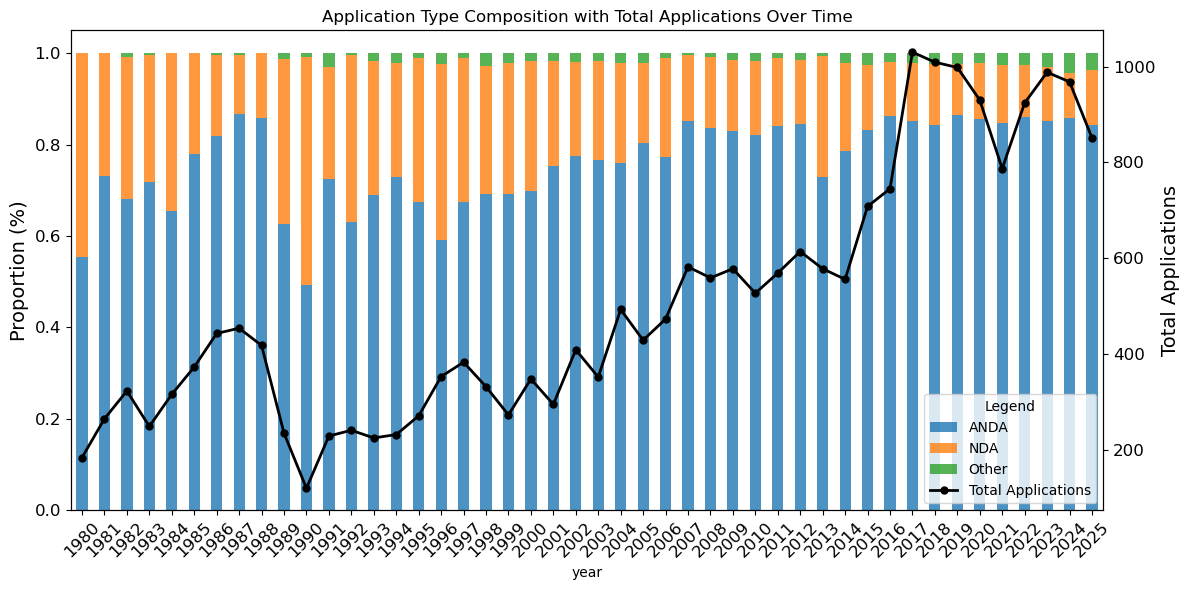

In [12]:
df = df_all.copy()
year_filter = 1980
# --- Filter to 1980+ ---
df = df[df["year"] >= year_filter].copy()

# classify NDA / ANDA / Other
# classify NDA / ANDA / Other
df["app_type"] = (
    df["application_number"]
      .str.extract(r"^(NDA|ANDA)", expand=False)
      .fillna("Other")
)

# compute totals and proportions
counts = df.groupby(["year", "app_type"], as_index=False).size()
totals_by_year = counts.groupby("year")["size"].sum().sort_index()
counts["proportion"] = counts["size"] / counts.groupby("year")["size"].transform("sum")

pivot = counts.pivot(index="year", columns="app_type", values="proportion").fillna(0)
pivot = pivot.sort_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# stacked bars
bar_plot = pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax1,
    alpha=0.8
)

# x positions of bars
x_positions = np.arange(len(pivot.index))

# total applications line
ax2 = ax1.twinx()
line_plot, = ax2.plot(
    x_positions,
    totals_by_year.values,
    marker="o",
    color="black",
    linewidth=2,
    markersize=5,
    zorder=10,
    label="Total Applications"
)

# axis labels
ax1.set_ylabel("Proportion (%)", fontsize=14)
ax2.set_ylabel("Total Applications",fontsize=14)
ax1.set_title("Application Type Composition with Total Applications Over Time")

# x-axis tick labels
ax1.set_xticks(x_positions)
ax1.set_xticklabels(pivot.index, rotation=45)

ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)

# --- MERGE LEGENDS (bars + line) ---
bar_handles, bar_labels = ax1.get_legend_handles_labels()
line_handles = [line_plot]
line_labels = ["Total Applications"]

ax1.legend(
    bar_handles + line_handles,
    bar_labels + line_labels,
    title="Legend",
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [13]:
df_all["year"] = df_all["year"].astype(int)

# Pick the years to compare
years_to_compare = [2010, 2013, 2017, 2020, 2023]

# Filter your dataset
df_compare = df_all[df_all["year"].isin(years_to_compare)].copy()

# Fill NaN submission class with something meaningful
df_compare["submission_class_code_description"] = (
    df_compare["submission_class_code_description"]
    .fillna("Unknown / Not Specified")
    .replace("", "Unknown / Not Specified")
)

# Group and count each submission class description per year
pivot = (
    df_compare
    .groupby(["submission_class_code_description", "year"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Sort by latest year or overall total
pivot = pivot.sort_values(by=years_to_compare[-1], ascending=False)

# Add total row
pivot.loc["Total"] = pivot.sum()

pivot

year,2010,2013,2017,2020,2023
submission_class_code_description,,,,,
Unknown / Not Specified,432,321,859,800,842
Type 1 - New Molecular Entity,20,25,44,53,52
Type 5 - New Formulation or New Manufacturer,20,26,43,24,35
Type 3 - New Dosage Form,29,27,28,22,27
Type 4 - New Combination,16,6,17,8,13
Not Applicable,1,101,21,5,4
Type 2 - New Active Ingredient,0,3,3,4,4
Type 1 - New Molecular Entity and Type 4 - New Combination,1,2,3,2,3
Type 10 - New Indication Submitted as Distinct NDA - Not Consolidated,0,0,1,3,3


## NME vs other approval types over time

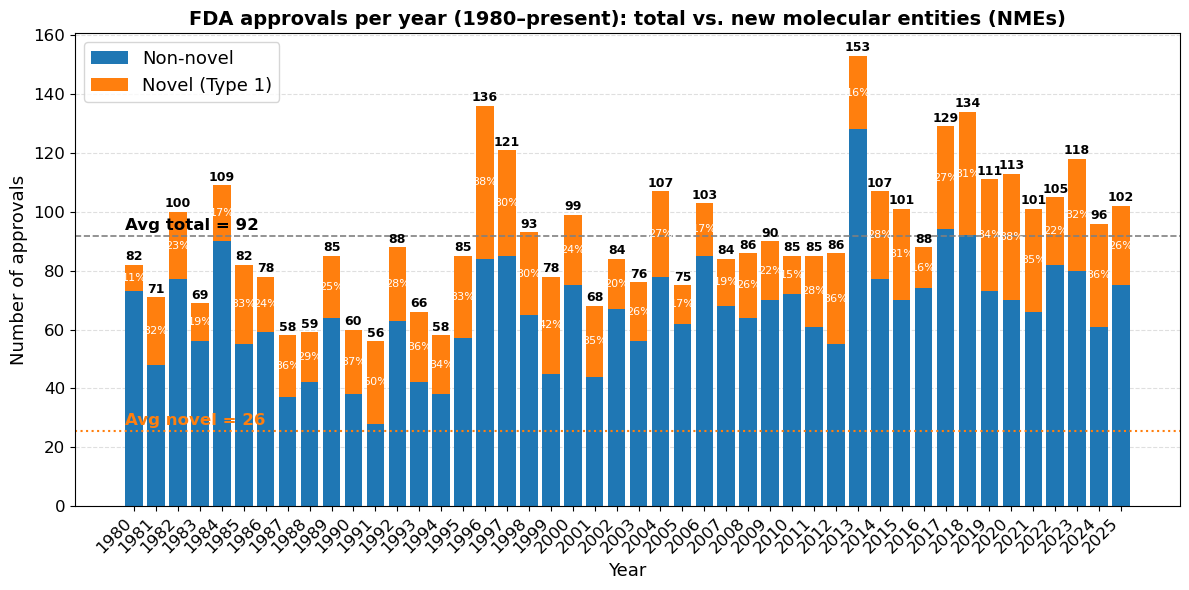

In [14]:
# --- Ensure dtypes ---
df_all["year"] = pd.to_numeric(df_all["year"], errors="coerce").astype("Int64")
df_all["is_novel_drug_therapy"] = df_all["is_novel_drug_therapy"].fillna(False).astype(bool)
df_all["is_repurposed_therapy"] = df_all["is_repurposed_therapy"].fillna(False).astype(bool)

year_filter = 1980
# --- Filter to 1980+ ---
df_1980 = df_all[df_all["year"] >= year_filter].copy()

df_1980 = df_1980[df_1980["application_number"].str.startswith("NDA", na=False)]

# --- Aggregate per year ---
yearly = (
    df_1980.groupby("year")
    .agg(total=("application_number", "size"),
         novel=("is_novel_drug_therapy", "sum"))
    .dropna(subset=["total"])
    .sort_index()
)
yearly["non_novel"] = yearly["total"] - yearly["novel"]

# --- Averages over 1980+ period ---
avg_total = yearly["total"].mean()
avg_novel = yearly["novel"].mean()

# --- Prep arrays for plotting (use positional x to avoid dtype issues) ---
years = yearly.index.astype("int64").to_numpy()
x = np.arange(len(years))
total = yearly["total"].to_numpy()
non_novel = yearly["non_novel"].to_numpy()
novel = yearly["novel"].to_numpy()

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

# Stacked bars
ax.bar(x, non_novel, label="Non-novel")
ax.bar(x, novel, bottom=non_novel, label="Novel (Type 1)")

# Total numbers on top of each bar
for xi, tot in zip(x, total):
    ax.text(xi, tot + 0.5, f"{int(tot)}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Novel proportion (%) inside the novel segment
for xi, base, nv, tot in zip(x, non_novel, novel, total):
    if nv > 0 and tot > 0:
        prop = nv / tot
        ax.text(xi, base + nv/2, f"{prop:.0%}", ha="center", va="center", fontsize=8, color="white")

# Average lines (single y-axis)
ax.axhline(avg_total, color="gray", linestyle="--", linewidth=1.2)
ax.text(-0.4, avg_total + 1, f"Avg total = {avg_total:.0f}", va="bottom", fontsize=12, fontweight="bold")

ax.axhline(avg_novel, color="tab:orange", linestyle=":", linewidth=1.5)
ax.text(-0.4, avg_novel + 1, f"Avg novel = {avg_novel:.0f}", va="bottom", color="tab:orange", fontsize=12, fontweight="bold")

# Labels & style
ax.set_title(f"FDA approvals per year ({str(year_filter)}–present): total vs. new molecular entities (NMEs)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Number of approvals", fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years], rotation=45, ha="right")
ax.tick_params(axis="both", labelsize=12)


ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=True, fontsize=13)

plt.tight_layout()
plt.show()


In [15]:
# Starting from your original df, e.g. df_orig
df = df_all.copy()
print(df.shape)
df = df[df["application_number"].str.startswith("NDA", na=False)]
print(df.shape)

df["submission_class_code_description"] = (
    df["submission_class_code_description"]
    .fillna("Unknown / Not Specified")
    .replace("", "Unknown / Not Specified")
)
# If one row == one NDA submission, use size():
df_counts = (
    df.groupby(["year", "submission_class_code_description"])
      .size()
      .reset_index(name="count")
)
df_counts

(25712, 7)
(5387, 7)


,year,submission_class_code_description,count
0,1939,Unknown / Not Specified,7
1,1940,Type 4 - New Combination,1
2,1940,Type 5 - New Formulation or New Manufacturer,1
3,1940,Unknown / Not Specified,1
4,1941,Type 5 - New Formulation or New Manufacturer,1
...,...,...,...
611,2025,Type 3 - New Dosage Form and Type 4 - New Comb...,1
612,2025,Type 4 - New Combination,4
613,2025,Type 5 - New Formulation or New Manufacturer,25
614,2025,Type 7 - Drug Already Marketed without Approve...,1


In [16]:
df_counts.submission_class_code_description.unique()


array(['Unknown / Not Specified', 'Type 4 - New Combination',
       'Type 5 - New Formulation or New Manufacturer',
       'Type 1 - New Molecular Entity', 'Type 3 - New Dosage Form',
       'Type 2 - New Active Ingredient',
       'Type 1 - New Molecular Entity and Type 4 - New Combination',
       'Type 2 New Active Ingredient and Type 4 New Combination',
       'Type 6 - New Indication (no longer used)',
       'Type 2 - New Active Ingredient and Type 3 - New Dosage Form',
       'Type 3 - New Dosage Form and Type 4 - New Combination',
       'Type 8 - Partial Rx to OTC Switch',
       'Type 7 - Drug Already Marketed without Approved NDA',
       'Type 9 - New Indication Submitted as Distinct NDA, Consolidated with Original NDA after Approval',
       'Efficacy', 'Medical Gas',
       'Type 10 - New Indication Submitted as Distinct NDA - Not Consolidated',
       'New Combination and New Formulation or New Manufacturer'],
      dtype=object)

## Different New Drug Approval types over time

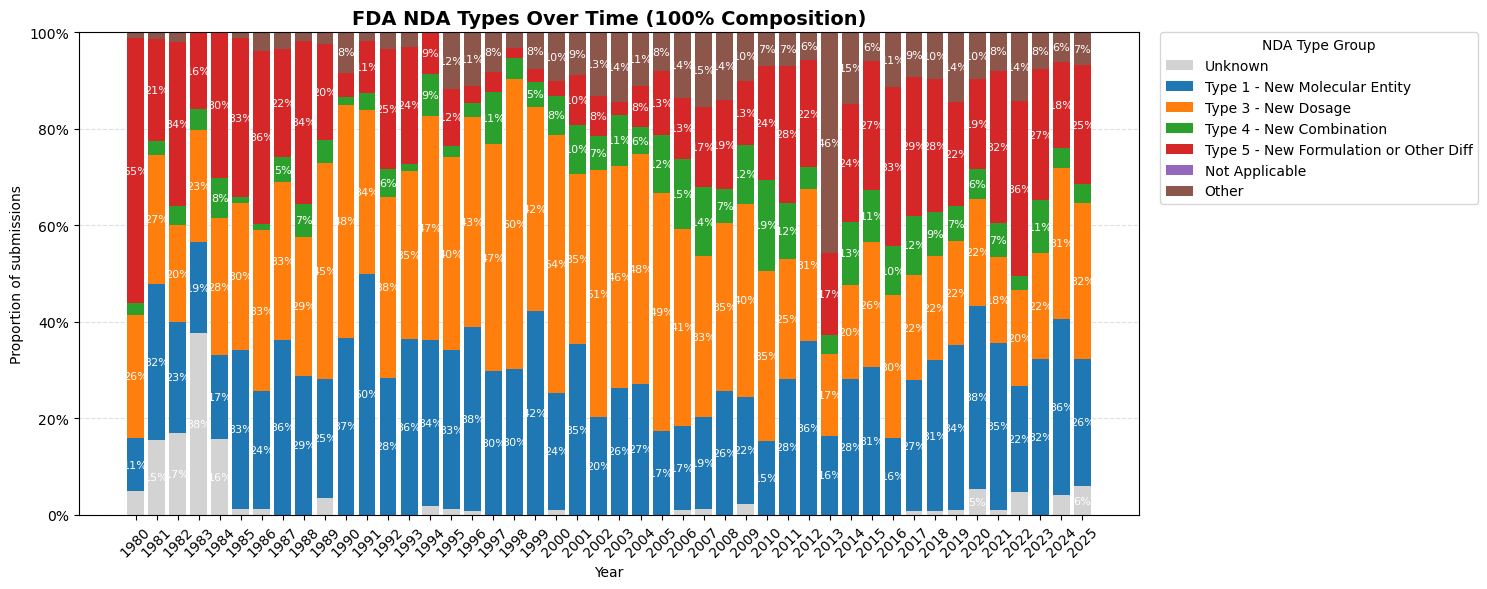

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = df_counts.copy()
year_filter = 1980

# --- Filter by year ---
df = df[df["year"] >= year_filter].copy()

# --- 1. Map raw class strings into groups ---

def collapse_type(cat: str) -> str:
    if cat == "Type 1 - New Molecular Entity":
        return "Type 1 - New Molecular Entity"
    if cat == "Type 1 - New Molecular Entity and Type 4 - New Combination":
        # count these as Type 1 as well
        return "Type 1 - New Molecular Entity"

    if cat.startswith("Type 3"):
        return "Type 3 - New Dosage"

    if cat.startswith("Type 4") and "Type 3" not in cat:
        return "Type 4 - New Combination"

    if cat.startswith("Type 5"):
        return "Type 5 - New Formulation or Other Diff"

    if cat.startswith("Unknown / Not Specified"):
        return "Unknown"

    if cat.startswith("Not Applicable"):
        return "Not Applicable"

    return "Other"

df["class_group"] = df["submission_class_code_description"].apply(collapse_type)

# --- 2. Aggregate counts per year per group ---

yearly = (
    df.groupby(["year", "class_group"])["count"]
      .sum()
      .reset_index()
)

# Pivot into matrix for stacked bars
pivot = yearly.pivot(index="year", columns="class_group", values="count").fillna(0)

# --- 3. Ensure consistent category order ---
# Put Unknown FIRST so it's the background / bottom of the stack
cols_order = [
    "Unknown",
    "Type 1 - New Molecular Entity",
    "Type 3 - New Dosage",
    "Type 4 - New Combination",
    "Type 5 - New Formulation or Other Diff",
    "Not Applicable",
    "Other",
]

for col in cols_order:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[cols_order]

# --- 4. Convert counts → proportions (100% stacked bar) ---

prop = pivot.div(pivot.sum(axis=1), axis=0)

# --- 5. Plot ---

years = prop.index.astype(int).to_numpy()
x = np.arange(len(years))

fig, ax = plt.subplots(figsize=(15, 6))

bottom = np.zeros(len(years))

for col in cols_order:
    values = prop[col].to_numpy()
    if col == "Unknown":
        # gray background segment
        ax.bar(x, values, bottom=bottom, label=col, color="lightgray")
    else:
        ax.bar(x, values, bottom=bottom, label=col)
    bottom += values

# --- 6. Add percentage labels inside bars ---
for i, year in enumerate(years):
    cum = 0
    for col in cols_order:
        val = prop.loc[year, col]
        if val > 0.05:  # threshold for visibility
            ax.text(
                i, cum + val/2, f"{val:.0%}",
                ha="center", va="center",
                fontsize=8, color="white"
            )
        cum += val

# --- 7. Style ---

ax.set_title("FDA NDA Types Over Time (100% Composition)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion of submissions")
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)

ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f"{int(v*100)}%" for v in np.linspace(0, 1, 6)])

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Legend ordered like bars (already in cols_order) and placed outside
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    title="NDA Type Group",
    frameon=True,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.
)

plt.tight_layout()
plt.show()
